In [1]:
import sys
from astropy import units as un, constants as cons
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from matplotlib import pyplot as plt
import cmasher as cmr
from astropy.visualization import quantity_support
quantity_support()

from cgm_ics.latexify import latexify
from cgm_ics import solve_ode as CF
from cgm_ics import HaloPotential as Halo
from cgm_ics import cooling_functions as Cool
from cgm_ics import ClusterGenerator as CG

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

In [2]:
# Set Cosmology
rho_crit = cosmo.critical_density0
rho_mean = cosmo.Om0*rho_crit
delta_c =  18 * np.pi**2 + 82 * (cosmo.Om0 - 1) - 39 * (cosmo.Om0 - 1)**2 # Bryan & Norman 98
mu = 0.62 # mean molecular weight

print(cosmo)

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)


In [3]:
# Helper function for dervied values
def calc_r_vir(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / delta_c / rho_crit, 1/3)
    return r_vir.to('kpc')

def calc_r_200_c(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_crit, 1/3)
    return r_vir.to('kpc')
    
def calc_r_200_m(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_mean, 1/3)
    return r_vir.to('kpc')

def calc_T_vir(M_vir):
    r_vir = calc_r_vir(M_vir)
    vc = np.sqrt(cons.G * M_vir / r_vir)
    temp = mu*cons.m_p*vc**2/cons.k_B/2
    return temp.to('K')

def calc_concentration(M_vir):
    h = cosmo.H0.value/100
    M_ref = 1e12/h * un.Msun
    log_c = 0.905 - 0.101*np.log10(M_vir/M_ref)
    return np.power(10, log_c)

def circular_temp(vc):
    temp = 0.6*mu*cons.m_p*vc**2/cons.k_B
    return temp.to('K')

In [4]:
# Set Halo Parameters
M_vir = 1e11 * un.Msun
r_vir = calc_r_vir(M_vir)
T_vir = calc_T_vir(M_vir)
c_vir = calc_concentration(M_vir) # Concentration parameter
r_200_m = calc_r_200_m(M_vir)
r_200_c = calc_r_200_c(M_vir)
M_gal = 1e10 * un.Msun # Greco et al 2012 for M82
r_gal = 0.015*r_200_c # Kravtsoc 2013 expression for stellar half-mass radius
z_gal = 0.15 * un.kpc # Lim et al 2013 for M82

print(c_vir)
      
print("Halo Mass: ",np.log10(M_vir.value))
print("Virial Radius: ", r_vir)
print("Virial Temperature: ", T_vir)
print("Concentration Parameter: ", c_vir)
print("R200m: ", r_200_m)
print("R200c: ", r_200_c)
print("Disk Mass", M_gal)
print("Disk Scale Radius", r_gal)
print("Disk Scale Height", z_gal)

# Set Halo Potential
nfw = Halo.NFWPotential(M_vir, r_vir, c_vir)
plummer = Halo.PlummerPotential(M_gal, r_gal)
outer = Halo.OuterHaloPotential(rho_mean, r_200_m)
combined = Halo.CombinedPotential(M_vir, r_vir, c_vir, M_gal, r_gal, rho_mean, r_200_m)
miyamoto = Halo.MiyamotoNagaiPotential(M_gal, r_gal, z_gal)

print("NFW Scale Density: ", nfw.rho_s)

10.54718269190388
Halo Mass:  11.0
Virial Radius:  122.40315626626357 kpc
Virial Temperature:  131960.7175211719 K
Concentration Parameter:  10.54718269190388
R200m:  144.76736317842207 kpc
R200c:  97.94126310709676 kpc
Disk Mass 10000000000.0 solMass
Disk Scale Radius 1.4691189466064514 kpc
Disk Scale Height 0.15 kpc
NFW Scale Density:  3320989.038326563 solMass / kpc3


In [5]:
# Set Units
cu_length  = 3.0856775809623245e+21 * un.cm # kpc
cu_mass    = 3.036951775493658e+39 * un. g  # number density 0.1 cm^-3 when box size is 1 kpc
cu_time    = 3.15576e+15  * un.s            # 100 Myr

# Derived Units
cu_velocity = cu_length/cu_time # cm/s
cu_density = cu_mass/cu_length**3 # g/cm**3
cu_energy = cu_mass*cu_velocity**2 # erg
cu_pressure = cu_energy/cu_length**3 # erg/cm**3 or dyne/cm^2
cu_temperature = cu_velocity**2*mu*cons.m_p/cons.k_B # K

print(cu_velocity.to('km/s'))
print(cu_density.to('g/cm3'))
print(cu_temperature.to('K'))

9.777922215131456 km / s
1.0336803493720967e-25 g / cm3
7181.238455976716 K


In [6]:
print("Input Parameters in Code Units")
print(f"r_scale   = {(combined.r_s/cu_length).to('')}")
print(f"rho_scale = {(combined.rho_s/cu_density).to('')}")
print(f"mass_gal  = {(combined.M_gal/cu_mass).to('')}")
print(f"scale_gal = {(combined.a_gal/cu_length).to('')}")
print(f"z_gal     = {(z_gal/cu_length).to('')}")
print(f"r_200     = {(combined.R200/cu_length).to('')}")
print(f"rho_mean  = {(combined.rho_mean/cu_density).to('')}")


Input Parameters in Code Units
r_scale   = 11.605294026167536
rho_scale = 2.1743800590375333
mass_gal  = 6547.387043624801
scale_gal = 1.4691189468583334
z_gal     = 0.15000000002571764
r_200     = 144.7673632032426
rho_mean  = 2.5759499291277927e-05


Velocities updated with new profile
Mean velocity magnitude: 2.705
Velocity range: [0.216, 5.942]

Cluster Statistics:
----------------------------------------
n_clusters: 1500.00
total_mass_msun: 7.07e+07
mean_mass_msun: 4.71e+04
median_mass_msun: 2.01e+04
std_mass_msun: 8.77e+04
min_mass_msun: 1.00e+04
max_mass_msun: 9.73e+05
mean_radius_pc: 196.54
max_radius_pc: 498.83
mass_range_decades: 1.99e+00
mean_v_mag: 2.70
std_v_mag: 1.33
min_z_pc: -10.00
max_z_pc: 9.99
mean_z_pc: -0.19
mean_vz: 0.01
std_vz: 1.04


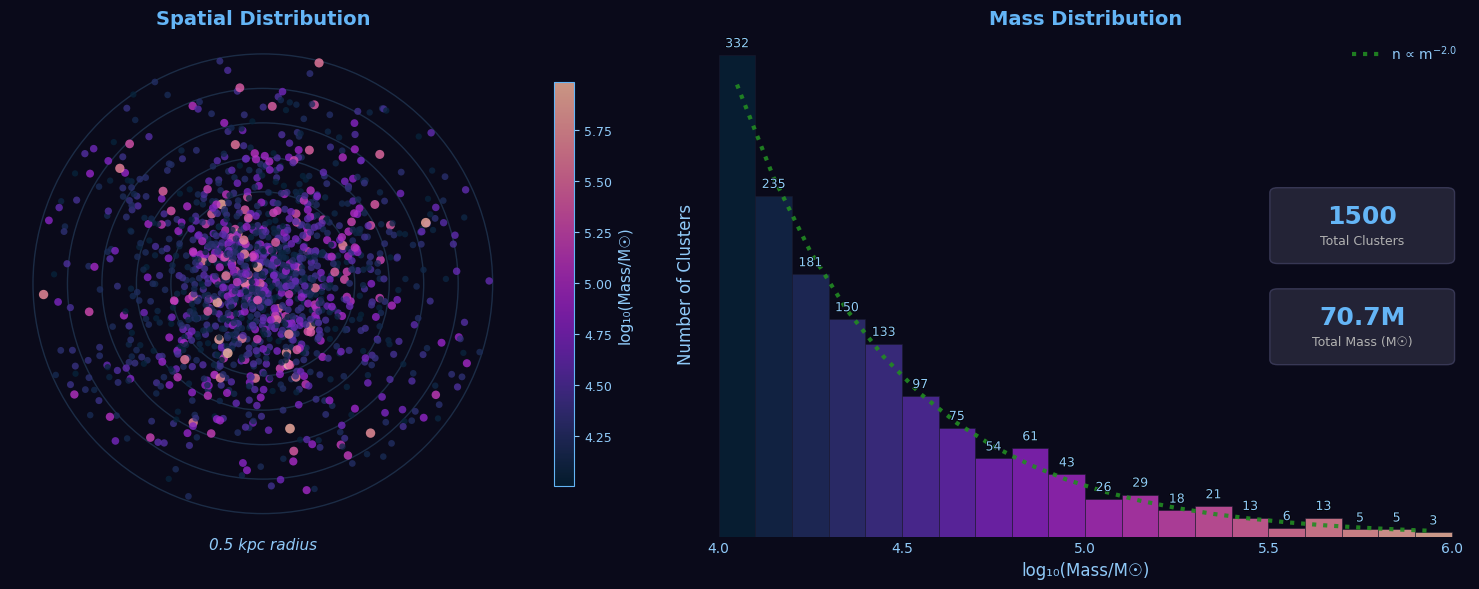

In [8]:
# Generate Star Clusters

params = CG.ClusterParameters(
    n_clusters=1500,
    mass_range=(1e4, 1e6),
    alpha=2.0,
    radius_kpc=0.5,
    spatial_profile='plummer',
    concentration=2.5  # scale radius = radius_pc / concentration = 200 pc
)

generator = CG.StarClusterGenerator(params)

# Generate clusters
clusters = generator.generate_clusters(seed=42)

# Set circular velocities
def get_vcirc(r):
    return (combined.vc(r*un.pc)/cu_velocity).to('')
generator.set_velocity_profile(get_vcirc)

# Display statistics
stats = generator.get_statistics()
print("\nCluster Statistics:")
print("-" * 40)
for key, value in stats.items():
    if 'mass' in key:
        print(f"{key}: {value:.2e}")
    else:
        print(f"{key}: {value:.2f}")

# Create visualization
# generator.plot_distributions(save_fig=False, filename='plots/clusters.pdf')
generator.plot_distributions(save_fig=True, filename='plots/clusters.png')

# # Save data to table
# generator.save_to_txt("tables/clusters_plummer.txt")
